In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


In [149]:
df = pd.read_parquet(r"D:\05_PROJECTS\supplychain\Supply Chain Intelligence Platform for Forecasting, Logistics, and Operational Analytics\cleaned_supplychain.parquet")

In [150]:
df.head()
pd.set_option('display.max_columns', None)
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Name,Product Price,shipping date (DateOrders),Shipping Mode,Order Year,Order Month,Order Quarter,Order Week,Shipping Delay,On_Time_Delivery,Profit Margin
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,Cally,20755,Holloway,Consumer,PR,5365 Noble Nectar Island,725.0,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.110000,0.04,180517,327.750000,0.29,1,327.750000,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,1360,Smart watch,327.750000,2018-02-03 22:56:00,Standard Class,2018,1,1,5,-1,1,27.841342
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,Irene,19492,Luna,Consumer,PR,2679 Rustic Loop,725.0,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.389999,0.05,179254,327.750000,-0.80,1,327.750000,311.359985,-249.089996,South Asia,Rajastán,PENDING,1360,Smart watch,327.750000,2018-01-18 12:27:00,Standard Class,2018,1,1,2,1,0,-75.999999
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,Gillian,19491,Maldonado,Consumer,CA,8510 Round Bear Gate,95125.0,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.030001,0.06,179253,327.750000,-0.80,1,327.750000,309.720001,-247.779999,South Asia,Rajastán,CLOSED,1360,Smart watch,327.750000,2018-01-17 12:06:00,Standard Class,2018,1,1,2,0,1,-75.600305
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,Tana,19490,Tate,Home Office,CA,3200 Amber Bend,90027.0,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.940001,0.07,179252,327.750000,0.08,1,327.750000,304.809998,22.860001,Oceania,Queensland,COMPLETE,1360,Smart watch,327.750000,2018-01-16 11:45:00,Standard Class,2018,1,1,2,-1,1,6.974829
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,Orli,19489,Hendricks,Corporate,PR,8671 Iron Anchor Corners,725.0,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.500000,0.09,179251,327.750000,0.45,1,327.750000,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,1360,Smart watch,327.750000,2018-01-15 11:24:00,Standard Class,2018,1,1,2,-2,1,40.948896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,Fishing,Brooklyn,EE. UU.,Maria,1005,Peterson,Home Office,NY,1322 Broad Glade,11207.0,Fan Shop,40.640930,-73.942711,Pacific Asia,Shanghái,China,1005,2016-01-16 03:40:00,26043,1004,0.000000,0.00,65177,399.980011,0.10,1,399.980011,399.980011,40.000000,Eastern Asia,Shanghái,CLOSED,1004,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,2016-01-20 03:40:00,Standard Class,2016,1,1,2,0,1,10.000500
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,Fishing,Bakersfield,EE. UU.,Ronald,9141,Clark,Corporate,CA,7330 Broad Apple Moor,93304.0,Fan Shop,35.362545,-119.018700,Pacific Asia,Hirakata,Japón,9141,2016-01-16 01:34:00,26037,1004,4.000000,0.01,65161,399.980011,-1.55,1,399.980011,395.980011,-613.770019,Eastern Asia,Osaka,COM

## "The profit margins in the table above represent individual product orders, not the aggregate total." 

# Delivery Performance

In [151]:
delivery_counts = df['On_Time_Delivery'].value_counts()
print(delivery_counts)
late_deliveries = delivery_counts[0]
total_deliveries = len(df)

late_percentage = (late_deliveries / total_deliveries) * 100
print(f"Late delivery percentage: {late_percentage:.2f}%")

On_Time_Delivery
0    103400
1     77119
Name: count, dtype: int64
Late delivery percentage: 57.28%


In [152]:
delivery_counts_on_time = df['Shipping Delay'].value_counts()
print(delivery_counts_on_time)

Shipping Delay
 1    60647
 0    33753
 2    28718
-1    21700
-2    21666
 3     7052
 4     6983
Name: count, dtype: int64


In [153]:
on_time = delivery_counts_on_time[0]
on_time_percentage = (on_time / total_deliveries) * 100
print(f"On Time delivery percentage: {on_time_percentage:.2f}%")

On Time delivery percentage: 18.70%


In [154]:
fast_delivery = delivery_counts_on_time[-1] + delivery_counts_on_time[-2]
fast_percentage = (fast_delivery / total_deliveries) * 100
print(f"Fast delivery percentage: {fast_percentage:.2f}%")

Fast delivery percentage: 24.02%


In [155]:
avg_shipping_delay = df['Shipping Delay'].mean()
print('Average shipping delay:',avg_shipping_delay*24,'Hrs')

Average shipping delay: 13.57937945590215 Hrs


In [156]:
freq_Shipping_Mode = df['Shipping Mode'].mode()
print(freq_Shipping_Mode)

0    Standard Class
Name: Shipping Mode, dtype: str


In [157]:
shipping_summary = df.groupby('Shipping Mode').agg(
    total_orders=('On_Time_Delivery', 'count'),
    late_orders=('On_Time_Delivery', lambda x: (x == 0).sum()),
    on_time_orders=('On_Time_Delivery', lambda x: (x == 1).sum())
)

shipping_summary['late_%'] = (
    shipping_summary['late_orders'] /
    shipping_summary['total_orders']
) * 100

print(shipping_summary)

                total_orders  late_orders  on_time_orders      late_%
Shipping Mode                                                        
First Class            27814        27814               0  100.000000
Same Day                9737         4657            5080   47.827873
Second Class           35216        28078            7138   79.730804
Standard Class        107752        42851           64901   39.768171


In [158]:
df[df['Shipping Mode'] == 'First Class'][[
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Shipping Delay',
    'On_Time_Delivery'
]].head(10)

,Days for shipping (real),Days for shipment (scheduled),Shipping Delay,On_Time_Delivery
6,2,1,1,0
7,2,1,1,0
9,2,1,1,0
13,2,1,1,0
14,2,1,1,0
15,2,1,1,0
17,2,1,1,0
18,2,1,1,0
33,2,1,1,0
34,2,1,1,0


Shipping performance analysis reveals that First Class has the highest delay rate (100%), indicating that all First Class shipments exceeded their scheduled delivery time. This suggests that the promised delivery window for First Class is extremely strict (1 day), causing even small delays to be classified as late. In contrast, Standard Class shows the lowest delay rate (39.77%), making it relatively more reliable in meeting scheduled delivery commitments.

In [159]:
shipping_region = df.groupby('Order Region').agg(
    total_orders=('On_Time_Delivery', 'count'),
    late_orders=('On_Time_Delivery', lambda x: (x == 0).sum())
)

shipping_region['late_%'] = (
    shipping_region['late_orders'] /
    shipping_region['total_orders']
) * 100

shipping_region = shipping_region.sort_values(
    by='late_%',
    ascending=False
)

print(shipping_region)

                 total_orders  late_orders     late_%
Order Region                                         
Central Africa           1677         1018  60.703637
Western Europe          27109        15863  58.515622
South Asia               7731         4523  58.504721
South of  USA            4045         2350  58.096415
Southeast Asia           9539         5531  57.983017
East of USA              6915         4009  57.975416
West Asia                6009         3455  57.497088
East Africa              1852         1064  57.451404
Eastern Europe           3920         2252  57.448980
Central America         28341        16224  57.245686
South America           14935         8548  57.234684
Central Asia              553          316  57.142857
US Center                5887         3363  57.125871
Eastern Asia             7280         4130  56.730769
Southern Europe          9431         5350  56.727813
North Africa             3232         1832  56.683168
West of USA              799

In [160]:
shipping_Market	= df.groupby('Market').agg(
    total_orders=('On_Time_Delivery', 'count'),
    late_orders=('On_Time_Delivery', lambda x: (x == 0).sum())
)

shipping_Market['late_%'] = (
    shipping_Market['late_orders'] /
    shipping_Market['total_orders']
) * 100

shipping_Market = shipping_Market.sort_values(
    by='late_%',
    ascending=False
)

print(shipping_Market)

              total_orders  late_orders     late_%
Market                                            
Europe               50252        28989  57.687256
Pacific Asia         41260        23649  57.317014
USCA                 25799        14744  57.149502
LATAM                51594        29420  57.022134
Africa               11614         6598  56.810746


In [161]:
avg_delay_mode = df.groupby('Shipping Mode')['Shipping Delay'].mean()
print(avg_delay_mode)

Shipping Mode
First Class       1.000000
Same Day          0.478279
Second Class      1.990828
Standard Class   -0.004093
Name: Shipping Delay, dtype: float64


Shipping mode has a significant impact on delivery performance. Second Class exhibits the highest average delay (1.99 days), indicating severe delivery inefficiencies. Although First Class shows a 100% delay rate, its delays are limited to approximately 1 day per shipment. In contrast, Standard Class performs best, with near-zero average delay, suggesting it is the most reliable shipping mode for meeting delivery schedules.

In [162]:
ship_summary = df.groupby('Shipping Mode').agg(
    Total_Profit=('Order Profit Per Order', 'sum'),
    Avg_Delay=('Shipping Delay', 'mean'),
    Total_Orders=('Order Profit Per Order', 'count')
)

print(ship_summary)

                Total_Profit  Avg_Delay  Total_Orders
Shipping Mode                                        
First Class     6.431219e+05   1.000000         27814
Same Day        2.030184e+05   0.478279          9737
Second Class    7.503082e+05   1.990828         35216
Standard Class  2.370454e+06  -0.004093        107752


In [163]:
corr = df['Shipping Delay'].corr(df['Order Profit Per Order'])
print(corr)

-0.005384931869571299


In [164]:
delay_profit = df.groupby('Shipping Delay')['Order Profit Per Order'].mean()
print('shipping delay','avg profit')
print(delay_profit)

shipping delay avg profit
Shipping Delay
-2    23.423528
-1    21.516997
 0    22.532021
 1    21.940582
 2    21.246239
 3    19.941130
 4    21.561202
Name: Order Profit Per Order, dtype: float64


Analysis shows that shipping delay has a negligible direct impact on per-order profitability, with a correlation coefficient of −0.005, indicating almost no linear relationship between delivery delay and profit. Average profit per order remains relatively stable across different delay durations. However, shipping delays may still affect profitability indirectly by reducing customer satisfaction, increasing churn, and lowering future order volume. Therefore, the primary financial risk of shipping delays lies not in immediate profit loss per order, but in potential long-term revenue reduction due to decreased customer retention.

In [165]:
customer_orders = (
    df.groupby('Customer Id')
      .agg(
          Total_Orders=('Order Item Id', 'nunique'),
          Avg_Delay=('Shipping Delay', 'mean')
      )
      .reset_index()
)
customer_orders

,Customer Id,Total_Orders,Avg_Delay
0,1,1,2.000000
1,2,10,0.500000
2,3,18,-0.166667
3,4,14,0.571429
4,5,7,0.571429
...,...,...,...
20647,20753,1,2.000000
20648,20754,1,-2.000000
20649,20755,1,-1.000000
20650,20756,1,0.000000


In [166]:
corr = customer_orders['Avg_Delay'].corr(customer_orders['Total_Orders'])
print(corr)

-0.0025827863004672744


In [167]:
customer_delay = df.groupby('Customer Id').agg(
    Total_Orders=('Order Item Id', 'nunique'),
    Delay_Rate=('On_Time_Delivery', lambda x: (x == 0).mean())
)
customer_delay['Delay_Rate'].corr(customer_delay['Total_Orders'])

-0.003410245515360883

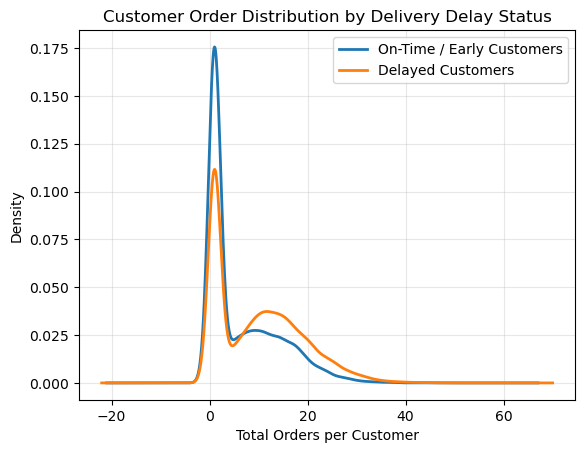

In [168]:
customer_orders['Delayed_Customer'] = (
    customer_orders['Avg_Delay'] > 0
)

customer_orders.groupby('Delayed_Customer')['Total_Orders'].plot(
    kind='kde',
    linewidth=2
)

plt.xlabel('Total Orders per Customer')
plt.ylabel('Density')
plt.title('Customer Order Distribution by Delivery Delay Status')
plt.legend(['On-Time / Early Customers', 'Delayed Customers'])
plt.grid(alpha=0.3)
plt.show()

KDE analysis of customer order distributions shows that both delayed and non-delayed customers are concentrated at low order frequencies. However, customers experiencing delivery delays exhibit a broader distribution with a heavier tail toward higher order counts. This suggests that delayed deliveries are more common among high-frequency customers due to greater order exposure, rather than indicating that shipping delays directly influence customer purchasing behavior.

# Geographic Analysis 

In [169]:
market_sales = (
    df.groupby('Market')
      .agg(
          Total_Sales=('Sales', 'sum'),
      )
      .reset_index()
      .sort_values('Total_Sales', ascending=False)
)

market_sales.head()

,Market,Total_Sales
1,Europe,1.087240e+07
2,LATAM,1.027761e+07
3,Pacific Asia,8.273744e+06
4,USCA,5.066529e+06
0,Africa,2.294453e+06


In [170]:
market_coords = {
    'Europe': (54.5, 15.0),
    'LATAM': (-14.0, -60.0),
    'Pacific Asia': (15.0, 110.0),
    'USCA': (39.8, -98.5),
    'Africa': (1.5, 20.0)
}

market_sales['lat'] = market_sales['Market'].map(lambda x: market_coords[x][0])
market_sales['lon'] = market_sales['Market'].map(lambda x: market_coords[x][1])
color_map = {
    'Europe': '#1f77b4',        # blue
    'LATAM': '#ff7f0e',         # orange
    'Pacific Asia': '#2ca02c',  # green
    'USCA': '#d62728',          # red
    'Africa': '#9467bd'         # purple
}
fig = px.scatter_geo(
    market_sales,
    lat='lat',
    lon='lon',
    size='Total_Sales',
    hover_name='Market',
    hover_data={'Total_Sales': ':,.2f'},
    scope = 'world',
    color="Market",
    color_discrete_map=color_map 
)

fig.update_layout(
    title='Total Sales by Market',
    geo=dict(
        showland=True,
        showcountries=True
    )
)

fig.show()

In [171]:
market_profit = (
    df.groupby('Market')
      .agg(
          Total_Profit=('Order Profit Per Order', 'sum'),
      )
      .reset_index()
      .sort_values('Total_Profit', ascending=False)
)

market_profit.head()


,Market,Total_Profit
1,Europe,1.169443e+06
2,LATAM,1.123322e+06
3,Pacific Asia,8.577534e+05
4,USCA,5.643138e+05
0,Africa,2.520712e+05


In [172]:
market_coords = {
    'Europe': (54.5, 15.0),
    'LATAM': (-14.0, -60.0),
    'Pacific Asia': (15.0, 110.0),
    'USCA': (39.8, -98.5),
    'Africa': (1.5, 20.0)
}

market_profit['lat'] = market_profit['Market'].map(lambda x: market_coords[x][0])
market_profit['lon'] = market_profit['Market'].map(lambda x: market_coords[x][1])
color_map = {
    'Europe': '#1f77b4',        # blue
    'LATAM': '#ff7f0e',         # orange
    'Pacific Asia': '#2ca02c',  # green
    'USCA': '#d62728',          # red
    'Africa': '#9467bd'         # purple
}
fig = px.scatter_geo(
    market_profit,
    lat='lat',
    lon='lon',
    size=market_profit['Total_Profit'].abs(),
    hover_name='Market',
    hover_data={'Total_Profit': ':,.2f'},
    scope = 'world',
    color="Market",
    color_discrete_map=color_map 
)

fig.update_layout(
    title='Total Profit by Market',
    geo=dict(
        showland=True,
        showcountries=True
    )
)

fig.show()

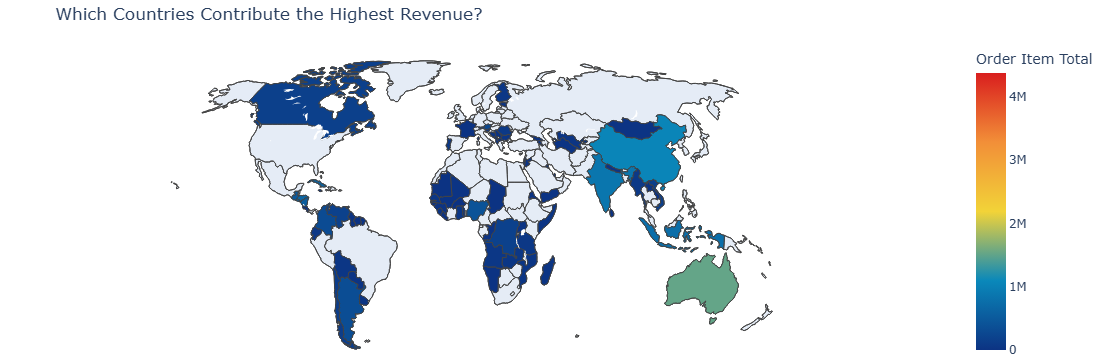

In [178]:
country_sales = df.groupby('Order Country', as_index=False)['Order Item Total'].sum()

fig = px.choropleth(
    country_sales,
    locations='Order Country',
    locationmode='country names',
    color='Order Item Total',
    hover_name='Order Country',
    color_continuous_scale='portland'
)

fig.update_layout(
    title='Which Countries Contribute the Highest Revenue?',
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    )
)
fig.update_layout(
    margin=dict(l=0, r=0, t=40, b=0),
    paper_bgcolor='white'
)

fig.update_geos(
    fitbounds="locations",
    showcountries=True,
    showcoastlines=True,
    showframe=False
)
fig.show()

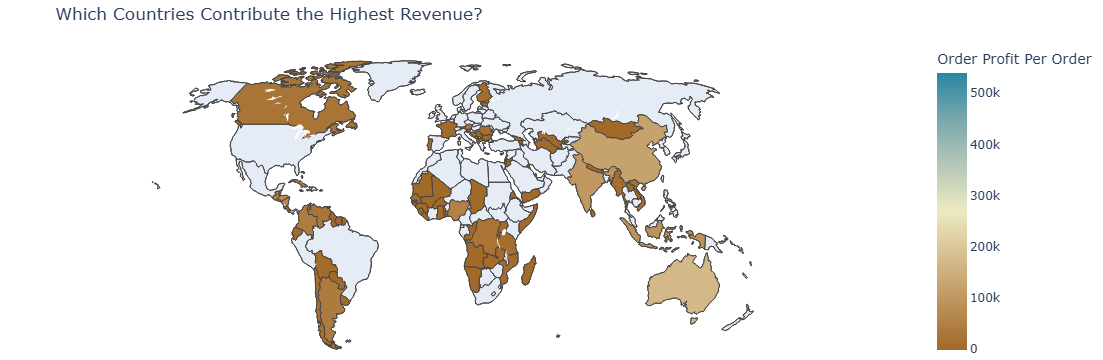

In [177]:
country_sales = df.groupby('Order Country', as_index=False)['Order Profit Per Order'].sum()

fig = px.choropleth(
    country_sales,
    locations='Order Country',
    locationmode='country names',
    color='Order Profit Per Order',
    hover_name='Order Country',
    color_continuous_scale='earth'
)

fig.update_layout(
    title='Which Countries Contribute the Highest Revenue?',
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    paper_bgcolor='white'
)

fig.update_geos(
    fitbounds="locations",
    showcountries=True,
    showcoastlines=True,
    showframe=False
)
fig.show()

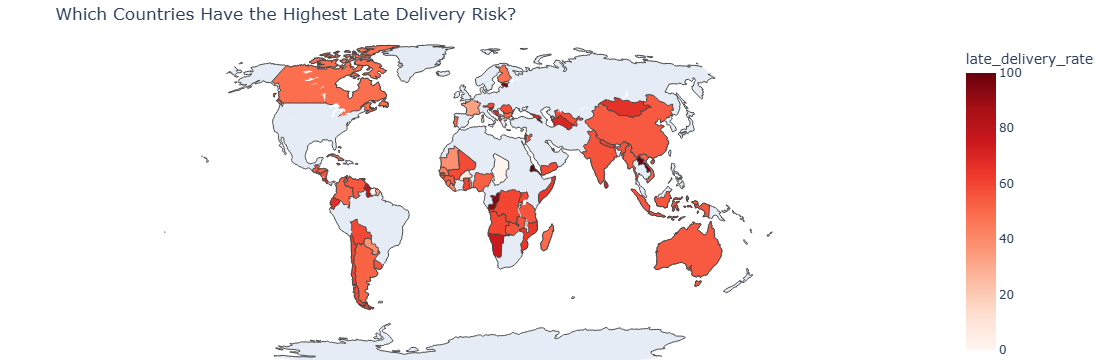

In [175]:
country_risk = (
    df.groupby('Order Country', as_index=False)
      .agg(
          total_orders=('Order Country', 'count'),
          late_orders=('Late_delivery_risk', 'sum')
      )
)
country_risk['late_delivery_rate'] = (
    country_risk['late_orders'] / country_risk['total_orders'] * 100
)

fig = px.choropleth(
    country_risk,
    locations='Order Country',
    locationmode='country names',
    color='late_delivery_rate',
    hover_name='Order Country',
    hover_data={
        'total_orders': True,
        'late_orders': True,
        'late_delivery_rate': ':.2f'
    },
    color_continuous_scale='Reds'
)

fig.update_layout(
    title='Which Countries Have the Highest Late Delivery Risk?',
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    paper_bgcolor='white'
)

fig.show()

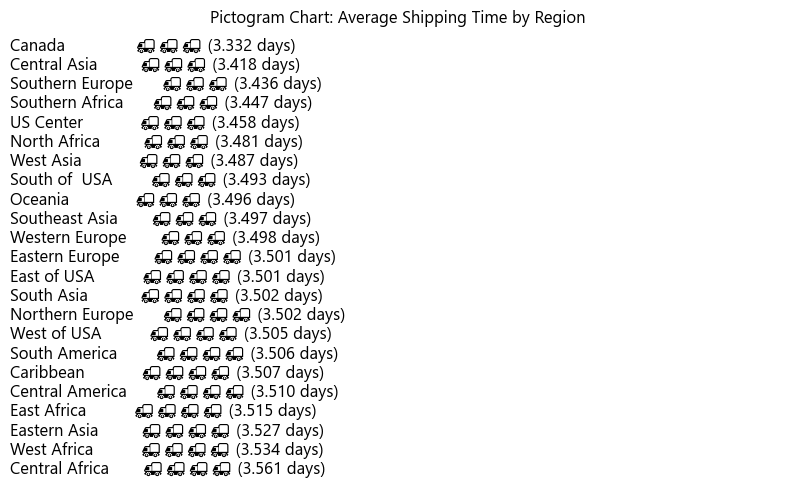

In [215]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'Segoe UI Emoji'  
# Step 1: compute average shipping time per region
region_shipping = (
    df.groupby('Order Region')['Days for shipping (real)']
      .mean()
      .sort_values(ascending=False)
)

# Step 2: choose icon
icon = "🚚"

# Step 3: plot pictogram
plt.figure(figsize=(10,6))

for i, (region, value) in enumerate(region_shipping.items()):
    icons = icon * int(round(value))   # repeat icon based on value
    
    plt.text(0, i, f"{region:20} {icons} ({value:.3f} days)", fontsize=12)

plt.xlim(0, 10)
plt.ylim(-1, len(region_shipping))

plt.title("Pictogram Chart: Average Shipping Time by Region")
plt.axis("off")

plt.show()